In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report

# Настройка стиля графиков для лучшего восприятия
plt.style.use('ggplot')

print("Библиотеки успешно импортированы!")
print(f"Версия TensorFlow: {tf.__version__}")

Библиотеки успешно импортированы!
Версия TensorFlow: 2.19.0


In [9]:
# Указываем пути к файлам согласно вашей файловой системе
# Загрузка датасета (Исправленная Ячейка 2)
base_dir = r"C:\Users\gsdasddj\Desktop\lab5"

# ВНИМАНИЕ: Поменяли T и E местами
# T = Train (Тренировочная), E = Evaluation (Тестовая)
train_data_path = os.path.join(base_dir, "MI-EEG-B9T.csv")
test_data_path = os.path.join(base_dir, "MI-EEG-B9E.csv")

# Загрузка таргетов остается без изменений
train_target_path = os.path.join(base_dir, "2class_MI_EEG_train_9.csv")
test_target_path = os.path.join(base_dir, "2class_MI_EEG_test_9.csv")

# Чтение CSV файлов
X_train_raw = pd.read_csv(train_data_path, header=None).values
X_test_raw = pd.read_csv(test_data_path, header=None).values

# Чтение меток
y_train = pd.read_csv(train_target_path, header=None).values.squeeze()
y_test = pd.read_csv(test_target_path, header=None).values.squeeze()

print("Данные успешно загружены!")
print("Проверка размерностей (X и y должны совпадать по первому числу):")
print(f"Тренировочные сигналы (X_train): {X_train_raw.shape} | Метки (y_train): {y_train.shape}")
print(f"Тестовые сигналы (X_test): {X_test_raw.shape} | Метки (y_test): {y_test.shape}")

Данные успешно загружены!
Проверка размерностей (X и y должны совпадать по первому числу):
Тренировочные сигналы (X_train): (400, 3000) | Метки (y_train): (400,)
Тестовые сигналы (X_test): (320, 3000) | Метки (y_test): (320,)


In [10]:
def eeg_to_scalogram(data, scales, waveletname='morl'):
    """
    Применяет непрерывное вейвлет-преобразование (CWT) к 1D сигналам ЭЭГ,
    преобразуя их в 2D изображения (скалограммы) для подачи в CNN.
    """
    n_samples = data.shape[0]
    n_scales = len(scales)
    n_timepoints = data.shape[1]

    # Инициализация тензора (образцы, высота, ширина, каналы) для Keras
    scalograms = np.zeros((n_samples, n_scales, n_timepoints, 1))

    print("Начинаю вейвлет-преобразование... Это может занять несколько минут.")
    for i in range(n_samples):
        signal = data[i, :]
        # CWT возвращает коэффициенты и частоты
        coeffs, _ = pywt.cwt(signal, scales, waveletname)

        # Берем модуль коэффициентов для получения амплитуды (энергии)
        scalograms[i, :, :, 0] = np.abs(coeffs)

        if (i + 1) % 50 == 0:
            print(f"Обработано {i + 1} из {n_samples} сигналов")

    print("Вейвлет-преобразование успешно завершено!")
    return scalograms

# Задаем масштабы (scales) от 1 до 32.
# Это определит разрешение (высоту) нашего итогового изображения.
scales = np.arange(1, 33)

Начинаю вейвлет-преобразование... Это может занять несколько минут.
Обработано 50 из 400 сигналов
Обработано 100 из 400 сигналов
Обработано 150 из 400 сигналов
Обработано 200 из 400 сигналов
Обработано 250 из 400 сигналов
Обработано 300 из 400 сигналов
Обработано 350 из 400 сигналов
Обработано 400 из 400 сигналов
Вейвлет-преобразование успешно завершено!
Начинаю вейвлет-преобразование... Это может занять несколько минут.
Обработано 50 из 320 сигналов
Обработано 100 из 320 сигналов
Обработано 150 из 320 сигналов
Обработано 200 из 320 сигналов
Обработано 250 из 320 сигналов
Обработано 300 из 320 сигналов
Вейвлет-преобразование успешно завершено!


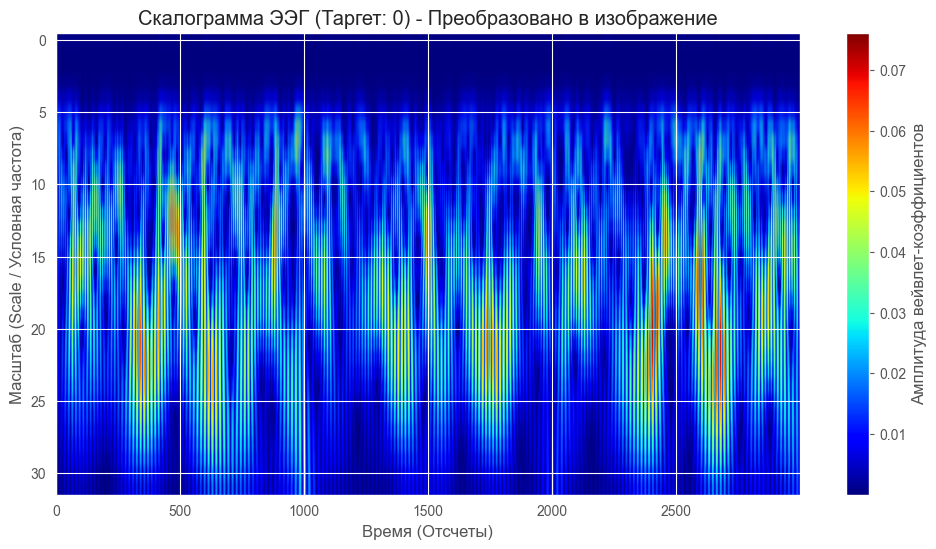

Новая размерность тренировочных данных (изображений): (400, 32, 3000, 1)


In [11]:
# Получаем изображения (скалограммы)
X_train_img = eeg_to_scalogram(X_train_raw, scales)
X_test_img = eeg_to_scalogram(X_test_raw, scales)

# Нормализация данных (значения от 0 до 1), что критически важно для нейросетей
max_val = np.max(X_train_img)
X_train_img = X_train_img / max_val
X_test_img = X_test_img / max_val

# Визуализируем преобразованный ЭЭГ сигнал
plt.figure(figsize=(12, 6))
# Отображаем первое изображение из тренировочной выборки
plt.imshow(X_train_img[0, :, :, 0], aspect='auto', cmap='jet')
plt.colorbar(label='Амплитуда вейвлет-коэффициентов')
plt.title(f"Скалограмма ЭЭГ (Таргет: {y_train[0]}) - Преобразовано в изображение")
plt.ylabel("Масштаб (Scale / Условная частота)")
plt.xlabel("Время (Отсчеты)")
plt.show()

print(f"Новая размерность тренировочных данных (изображений): {X_train_img.shape}")

In [12]:
# Нейронные сети ожидают метки классов начиная с 0 (например, 0 и 1 для бинарной классификации)
# Проверяем уникальные значения
unique_labels = np.unique(y_train)
print(f"Оригинальные метки классов: {unique_labels}")

# Если метки представлены как 1 и 2, сдвигаем их к 0 и 1
if np.min(y_train) == 1:
    y_train = y_train - 1
    y_test = y_test - 1
    print("Метки были сдвинуты к диапазону [0, 1] для корректной работы нейросети.")
else:
    print("Метки уже находятся в корректном формате.")

print(f"Метки для тренировки: {np.unique(y_train)}")

Оригинальные метки классов: [0 1]
Метки уже находятся в корректном формате.
Метки для тренировки: [0 1]


In [13]:
# Получаем форму одного "изображения" (высота, ширина, каналы)
input_shape = (X_train_img.shape[1], X_train_img.shape[2], 1)

# Строим модель
model = models.Sequential([
    # Первый сверточный блок
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    # Второй сверточный блок
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Разворачиваем карты признаков в одномерный вектор
    layers.Flatten(),

    # Полносвязные слои для финальной классификации
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Регуляризация (предотвращает переобучение)
    layers.Dense(1, activation='sigmoid') # Выходной слой для бинарной классификации (левый/правый кулак)
])

# Компиляция модели
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Архитектура нейронной сети успешно создана!")
model.summary()

D:\Python\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Архитектура нейронной сети успешно создана!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 3000, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 1500, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 1500, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 750, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 384000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │    24,576,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,594,945 (93.82 MB)

 Trainable params: 24,594,945 (93.82 MB)

 Non-trainable params: 0 (0.00 B)

Запуск процесса обучения нейронной сети...
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.4140 - loss: 0.8075 - val_accuracy: 0.7250 - val_loss: 0.6921
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5708 - loss: 0.6921 - val_accuracy: 0.7375 - val_loss: 0.6925
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5636 - loss: 0.6918 - val_accuracy: 0.7625 - val_loss: 0.6907
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6192 - loss: 0.6883 - val_accuracy: 0.6375 - val_loss: 0.6840
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.5743 - loss: 0.6832 - val_accuracy: 0.7625 - val_loss: 0.6725
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6444 - loss: 0.6627 - val_accuracy: 0.8000 - val_loss: 0.6520
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.6261 - loss: 0.6544 - val_accuracy: 0.7750 - val_loss: 0.6317
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.7335 - loss

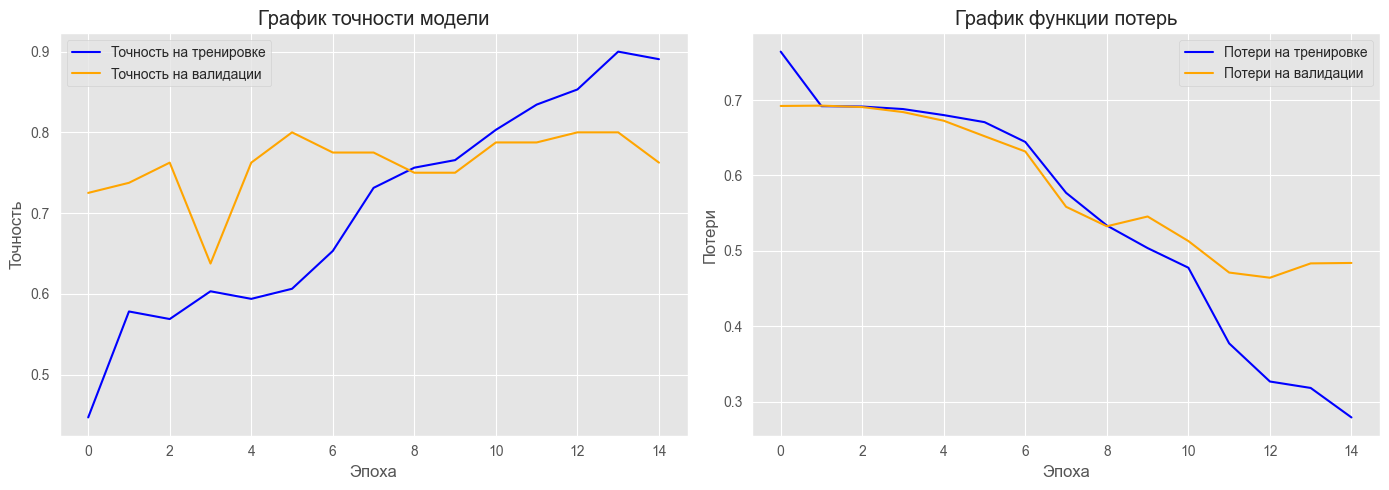

In [14]:
print("Запуск процесса обучения нейронной сети...")

# Обучаем модель с валидацией на 20% данных
history = model.fit(
    X_train_img,
    y_train,
    epochs=15,          # Количество проходов по датасету
    batch_size=32,      # Размер мини-выборки
    validation_split=0.2, # Отделяем часть данных для проверки
    verbose=1
)

# Визуализация результатов обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График точности (Accuracy)
ax1.plot(history.history['accuracy'], label='Точность на тренировке', color='blue')
ax1.plot(history.history['val_accuracy'], label='Точность на валидации', color='orange')
ax1.set_title('График точности модели')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Точность')
ax1.legend()

# График функции потерь (Loss)
ax2.plot(history.history['loss'], label='Потери на тренировке', color='blue')
ax2.plot(history.history['val_loss'], label='Потери на валидации', color='orange')
ax2.set_title('График функции потерь')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Потери')
ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
print("Оценка модели на неизвестных тестовых данных...")

# Получаем общую точность и потери
test_loss, test_acc = model.evaluate(X_test_img, y_test, verbose=0)
print(f"\nИтоговая точность на тестовой выборке: {test_acc * 100:.2f}%\n")

# Получаем предсказания модели
y_pred_probs = model.predict(X_test_img)
# Переводим вероятности в бинарные классы (порог 0.5)
y_pred = (y_pred_probs > 0.5).astype(int).squeeze()

# Выводим подробный отчет по метрикам
print("Отчет о классификации (Представление о движении):")
target_names = ['Левый кулак (Класс 0)', 'Правый кулак (Класс 1)']
print(classification_report(y_test, y_pred, target_names=target_names))

Оценка модели на неизвестных тестовых данных...

Итоговая точность на тестовой выборке: 72.81%

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 429ms/step
Отчет о классификации (Представление о движении):
                        precision    recall  f1-score   support

 Левый кулак (Класс 0)       0.69      0.83      0.75       160
Правый кулак (Класс 1)       0.79      0.62      0.70       160

              accuracy                           0.73       320
             macro avg       0.74      0.73      0.73       320
          weighted avg       0.74      0.73      0.73       320

